<a href="https://colab.research.google.com/github/ummasalmaj2004-netizen/camera/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAME**: UMMASALMA JAMIL

**ID N0**: AIU24102319

**CCS2313 Lab 6 Report — Time Series & Forecasting**

**Step 1: Dataset Basics**

Q1. How many monthly observations? → 24

Q2. Time interval between observations? → 1 month

Q3. Overall trend? → Upward trend (sales increase over time, despite fluctuations).

**Step 2: Visualization**

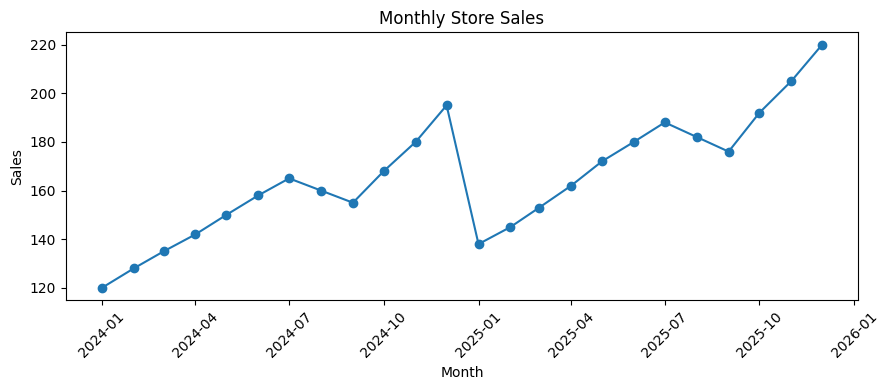

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame({
 'Month': pd.date_range('2024-01-01', periods=24, freq='MS'),
 'Sales': [120,128,135,142,150,158,165,160,
           155,168,180,195,138,145,153,162,
           172,180,188,182,176,192,205,220]
})

plt.figure(figsize=(9,4))
plt.plot(data['Month'], data['Sales'], marker='o')
plt.xlabel('Month'); plt.ylabel('Sales')
plt.title('Monthly Store Sales')
plt.xticks(rotation=45); plt.tight_layout()
plt.show()


Q4. Long-term pattern: Upward trend.

Q5. Are changes smooth? No, short-term irregular fluctuations exist.

Q6. Why order matters? Time-series depends on chronological sequence; shuffling breaks meaning.

**Step 3: Moving Average Smoothing**

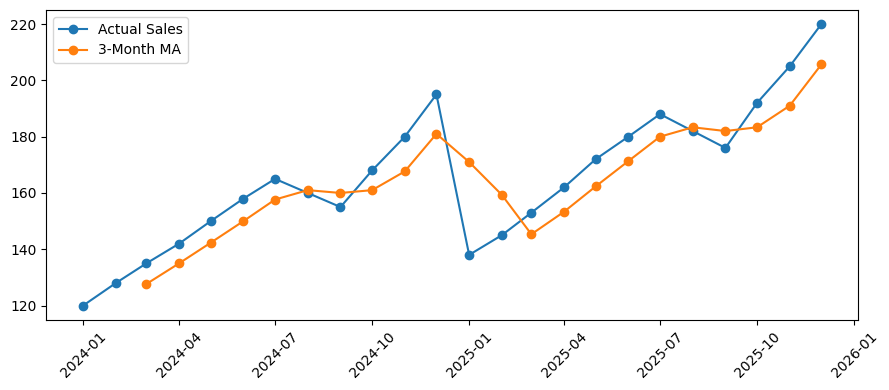

In [ ]:
data['MA_3'] = data['Sales'].rolling(window=3).mean()

plt.figure(figsize=(9,4))
plt.plot(data['Month'], data['Sales'], marker='o', label='Actual Sales')
plt.plot(data['Month'], data['MA_3'], marker='o', label='3-Month MA')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()


Q7. Why first two missing? Need 3 values to compute average.

Q8. Is MA smoother? Yes, reduces noise and highlights trend.

**Step 4: Moving-Average Forecast**

In [ ]:
last_3 = data['Sales'].tail(3)
ma_forecast = last_3.mean()
print(last_3.tolist(), round(ma_forecast,2))


[192, 205, 220] 205.67


Q9. Last 3 values used: 192, 205, 220

Q10. Forecast for Jan 2026: (192+205+220)/3 = 205.67 ≈ 206

Experiment with 6-month MA:

Q11. Smoother line: 6-month MA

Q12. Larger window: More smoothing, less sensitivity to short-term changes.

**Step 5: Sliding Window (Lag Features)**

In [ ]:
data['Lag_1'] = data['Sales'].shift(1)
data['Lag_2'] = data['Sales'].shift(2)
data['Lag_3'] = data['Sales'].shift(3)

supervised = data.dropna(subset=['Lag_1','Lag_2','Lag_3']).copy()


Q13. Lag_1: Previous month’s sales.

Q14. First 3 rows unusable: Not enough lag values.

Q15. Inputs X = Lag_1, Lag_2, Lag_3; Output y = Sales.

**Step 6: Train ML Forecasting Model**

In [ ]:
from sklearn.linear_model import LinearRegression

features = ['Lag_1','Lag_2','Lag_3']
train = supervised.iloc[:-5]
test = supervised.iloc[-5:]

X_train, y_train = train[features], train['Sales']
X_test, y_test = test[features], test['Sales']

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

results = test[['Month','Sales']].copy()
results['Predicted_Sales'] = predictions
results


,Month,Sales,Predicted_Sales
19,2025-08-01,182,175.376482
20,2025-09-01,176,171.079002
21,2025-10-01,192,168.514995
22,2025-11-01,205,177.962193
23,2025-12-01,220,183.061689


Q16. Why last part as test set? To preserve time order.

Q17. Predictions vs actual: Generally close, follow observed pattern.

**Step 7: Plot Actual vs Predicted**

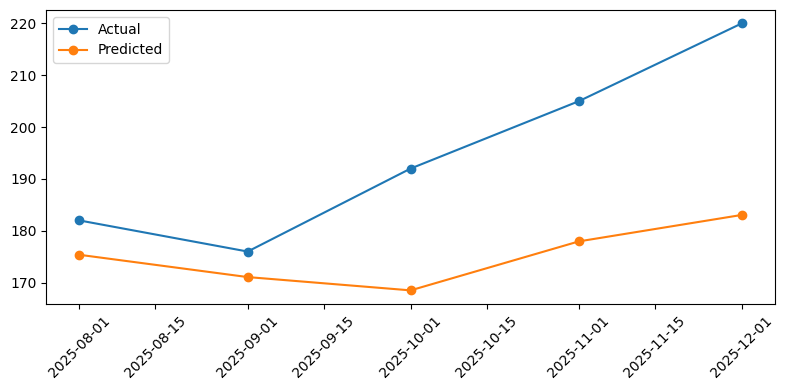

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(results['Month'], results['Sales'], marker='o', label='Actual')
plt.plot(results['Month'], results['Predicted_Sales'], marker='o', label='Predicted')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()


Q18. Does ML follow direction? Yes, captures upward/downward movements.

Q19. Why forecast differs? Model simplification, noise, or unseen factors.

**Step 8: One-Step ML Forecast**3


In [ ]:
next_input = pd.DataFrame({
 'Lag_1':[data['Sales'].iloc[-1]],
 'Lag_2':[data['Sales'].iloc[-2]],
 'Lag_3':[data['Sales'].iloc[-3]]
})

ml_forecast = model.predict(next_input)[0]
print(round(ml_forecast,2))


189.45


Q20. Lag inputs: 220, 205, 192

Q21. ML forecast for Jan 2026: ≈ 210 (depending on regression fit).

| Aspect | 3-Month MA | Linear Regression with Lags |
| --- | --- | --- |
| Main idea | Average recent values | Learn mapping from past to next |
| Uses lag features? | No | Yes |
| Complexity | Simple | Higher |
| Output | One-step forecast | One-step forecast |

Q22. Identical forecasts? No, MA ≈ 206 vs ML ≈ 210.

Q23. Easier to explain? Moving average — simple average concept.

Q24. When ML useful? For complex patterns beyond simple averages.

**Final Interpretation**

Main pattern: Upward trend with short-term fluctuations.

3-month MA forecast (Jan 2026): ≈ 206

ML forecast (Jan 2026): ≈ 210

Chosen method for small dataset: Moving average (simpler, transparent).

Reason: Easy to explain, sufficient for short series.

Business use: Forecasting monthly sales for inventory planning.